In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn

In [ ]:
path='/content/drive/MyDrive/ieee-fraud-detection/datasets'
files=os.listdir(path)
print(files)

['sample_submission.csv', 'test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv', 'y_train.npy', 'y_test.npy', 'X_train_scaled.npy', 'X_test_scaled.npy', 'feature_names.json']


In [ ]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import mlflow

In [ ]:
os.environ["MLFLOW_ALLOW_FILE_STORE"]="true"

mlflow.set_tracking_uri("file:///content/drive/MyDrive/ieee-fraud-detection/ml-flow-experiments")
mlflow.set_experiment("fraud_model_bakeoff")

<Experiment: artifact_location='file:///content/drive/MyDrive/ieee-fraud-detection/ml-flow-experiments/492684693097444956', creation_time=1784204345668, effective_trace_archival_retention=None, experiment_id='492684693097444956', last_update_time=1784204345668, lifecycle_stage='active', name='fraud_model_bakeoff', tags={}, trace_location=None, workspace='default'>

In [ ]:
runs=mlflow.search_runs(experiment_names=["fraud_model_bakeoff"])
finished_runs=runs[runs["status"]=="FINISHED"].sort_values("metrics.test_f1",ascending=False)
print(finished_runs[["run_id","tags.mlflow.runName"]].to_string())

                             run_id tags.mlflow.runName
3  e6997eb70fb1466ea45d29a0d021fb51            lightgbm
4  cc984fe4e9fc462ca5d8cbdcff713108             xgboost
0  802b22bb298f4e9e9d4cbba43f97f3bc          neural_net


In [ ]:
finished_runs_scores=runs[runs["status"]=="FINISHED"]
print(finished_runs_scores[["tags.mlflow.runName","metrics.test_f1","metrics.test_auc"]].to_string())

  tags.mlflow.runName  metrics.test_f1  metrics.test_auc
0          neural_net         0.601876          0.939448
3            lightgbm         0.723536          0.961212
4             xgboost         0.679606          0.953905


In [ ]:
import mlflow.lightgbm
import mlflow.pytorch
import mlflow.xgboost

In [ ]:
lgbm_model=mlflow.lightgbm.load_model(f"runs:/{'e6997eb70fb1466ea45d29a0d021fb51'}/model")
xgb_model=mlflow.xgboost.load_model(f"runs:/{'cc984fe4e9fc462ca5d8cbdcff713108'}/model")
mlp_model=mlflow.pytorch.load_model(f"runs:/{'802b22bb298f4e9e9d4cbba43f97f3bc'}/model", map_location=torch.device('cpu'))

2026/07/18 14:50:26 WARNING mlflow.pytorch: Stored model version '2.11.0+cu128' does not match installed PyTorch version '2.11.0+cpu'


In [ ]:
X_test=np.load(path+'/X_test_scaled.npy')
y_test=np.load(path+'/y_test.npy')

In [ ]:
with open(path+'/feature_names.json','r') as f:
  features=json.load(f)

In [ ]:
features_nn=[422, 8, 426, 420, 14, 1, 27, 26, 344, 308, 6, 24, 423, 9, 329, 3, 149, 19, 4, 424, 421, 430, 427, 180, 7, 358, 12, 18, 178, 47, 31, 15, 46, 141, 404, 5, 362, 0, 429, 28, 120, 41, 428, 36, 147, 418, 145, 45, 333, 332, 345, 99, 22, 21, 29, 341, 11, 2, 390, 394, 30, 425, 335, 103, 406, 37, 395, 330, 25, 137, 44, 34, 98, 152, 391, 23, 13, 405, 363, 410, 331, 132, 251, 79, 153, 60, 239, 357, 86, 95, 49, 215, 62, 146, 403, 300, 419, 338, 181, 237, 337, 88, 360, 32, 176, 133, 206, 112, 199, 70, 431, 412, 202, 126, 69, 106, 365, 55, 128, 35, 401, 307, 409, 417, 63, 177, 16, 85, 305, 367, 140, 271, 113, 125, 80, 94, 370, 61, 134, 368, 350, 400, 39, 114, 104, 250, 364, 89, 97, 282, 197, 346, 174, 339, 43, 324, 343, 111, 186, 392, 50, 184, 17, 84, 349, 124, 117, 253, 396, 136, 74, 296, 261, 247, 293, 374, 309, 119, 127, 238, 226, 402, 116, 150, 151, 348, 229, 73, 105, 135, 252, 227, 220, 159, 356, 347, 148, 352, 312, 214]

In [ ]:
X_test_nn=X_test[:,features_nn]

In [ ]:
model_prob={
    "lgbm": lgbm_model.predict(X_test),
    "xgboost": xgb_model.predict_proba(X_test)[:,1],
    "Neural Net": torch.sigmoid(mlp_model(torch.tensor(X_test_nn,dtype=torch.float32))).detach().cpu().numpy().ravel()
    }

In [ ]:
model_prob

{'lgbm': array([0.00107895, 0.01307123, 0.00148969, ..., 0.0124661 , 0.02185708,
        0.00244273]),
 'xgboost': array([0.00247793, 0.01495346, 0.00222779, ..., 0.01651354, 0.08222956,
        0.00590266], dtype=float32),
 'Neural Net': array([4.3301319e-05, 2.9457724e-01, 5.6447642e-04, ..., 5.7288801e-04,
        1.8909428e-01, 2.0583284e-03], dtype=float32)}

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report, roc_curve, auc, precision_recall_curve

In [ ]:
model_pred={
    model_name: np.where(model_val>=0.5,1,0) for model_name,model_val in model_prob.items()
}

In [ ]:
model_pred

{'lgbm': array([0, 0, 0, ..., 0, 0, 0]),
 'xgboost': array([0, 0, 0, ..., 0, 0, 0]),
 'Neural Net': array([0, 0, 0, ..., 0, 0, 0])}

In [ ]:
model_wise_positives={
    model_name: np.sum(model_pred[model_name]) for model_name in model_pred.keys()
}

In [ ]:
model_wise_positives

{'lgbm': np.int64(2631),
 'xgboost': np.int64(2359),
 'Neural Net': np.int64(5354)}

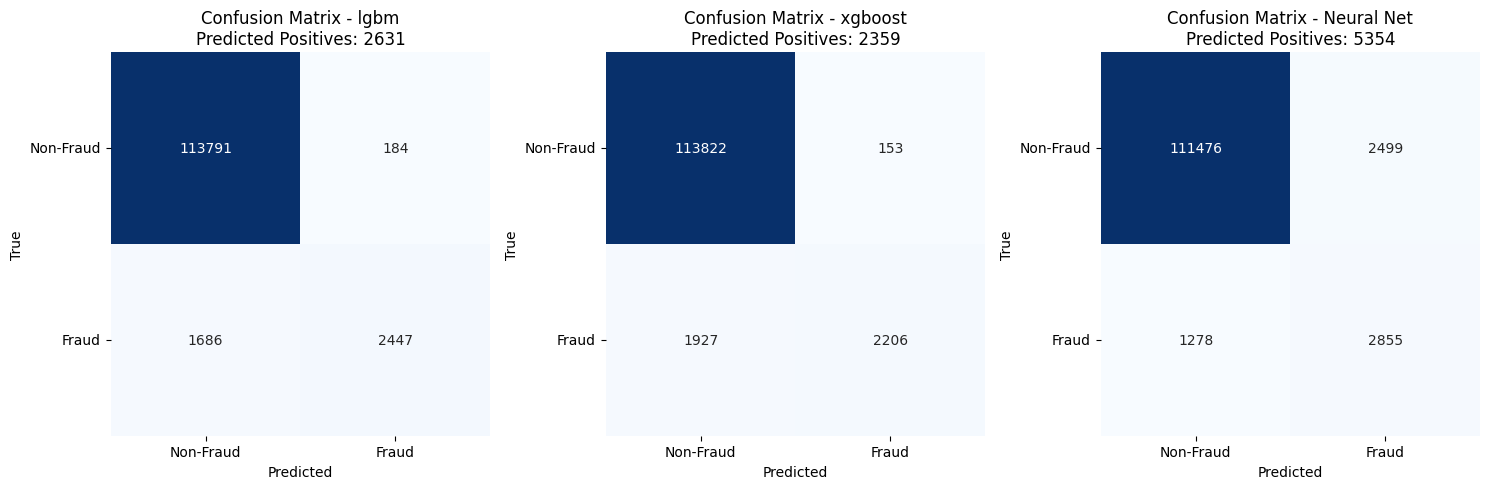

In [ ]:
plt.figure(figsize=(15, 5))

for i, (model_name, predictions) in enumerate(model_pred.items()):
    cm = confusion_matrix(y_test, predictions)

    plt.subplot(1, len(model_pred), i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}\nPredicted Positives: {model_wise_positives[model_name]}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks([0.5, 1.5], ['Non-Fraud', 'Fraud'])
    plt.yticks([0.5, 1.5], ['Non-Fraud', 'Fraud'], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
model_wise_cr={
    model_name: classification_report(y_test,model_pred[model_name]) for model_name in model_pred.keys()
}

In [ ]:
for model_name, report in model_wise_cr.items():
  print(f"--- Classification Report for {model_name} ---")
  print(report)
  print("\n")

--- Classification Report for lgbm ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.93      0.59      0.72      4133

    accuracy                           0.98    118108
   macro avg       0.96      0.80      0.86    118108
weighted avg       0.98      0.98      0.98    118108



--- Classification Report for xgboost ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.94      0.53      0.68      4133

    accuracy                           0.98    118108
   macro avg       0.96      0.77      0.84    118108
weighted avg       0.98      0.98      0.98    118108



--- Classification Report for Neural Net ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98    113975
           1       0.53      0.69      0.60      4133

    accuracy                           0.97    11810

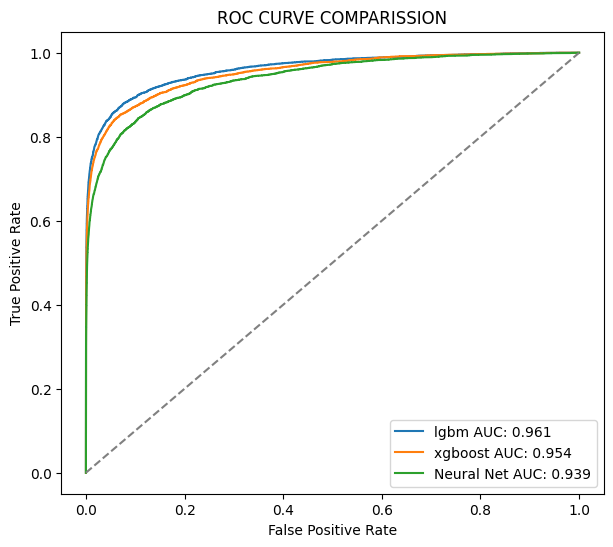

In [ ]:
plt.figure(figsize=(7,6))
for name,prob in model_prob.items():
  fpr,tpr,_=roc_curve(y_test,prob)
  plt.plot(fpr,tpr,label=f"{name} AUC: {auc(fpr,tpr):.3f}")

plt.plot([0,1],[0,1],linestyle="--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE COMPARISSION")
plt.legend()
plt.show()

In [ ]:
import shap

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


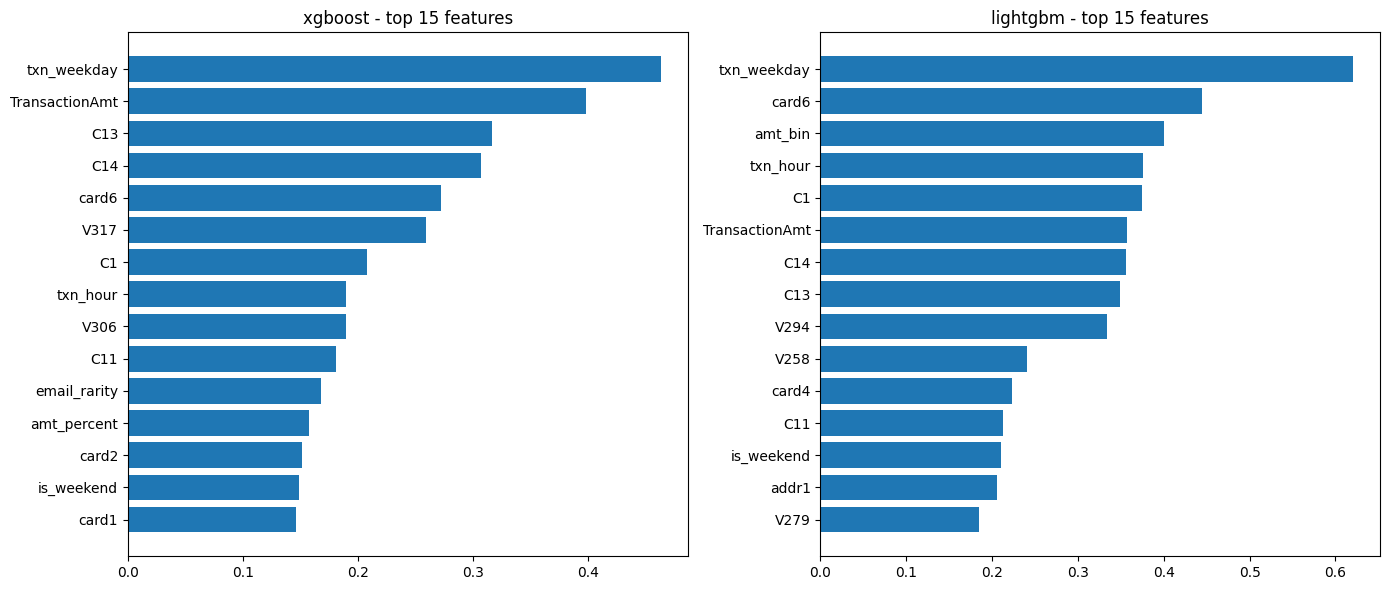

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
for ax,(name,model) in zip(axes,[("xgboost", xgb_model),("lightgbm", lgbm_model)]):
  explainer=shap.TreeExplainer(model)
  shap_values=explainer.shap_values(X_test)
  imp_features=pd.Series(abs(shap_values).mean(axis=0),index=features).sort_values(ascending=False).head(15)
  ax.barh(imp_features.index[::-1],imp_features.values[::-1])
  ax.set_title(f'{name} - top 15 features')

plt.tight_layout()
plt.show()

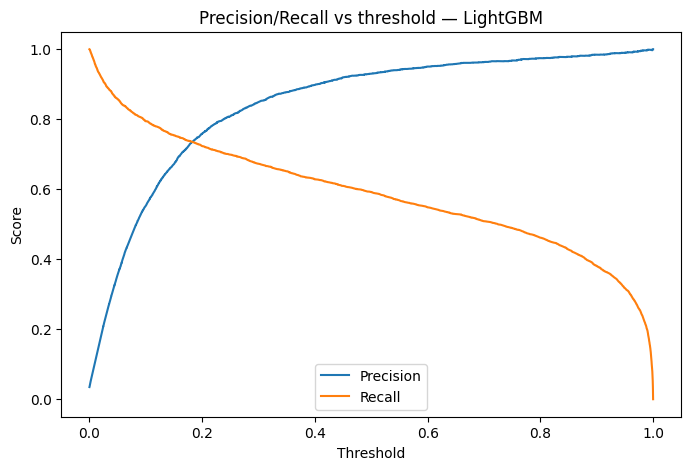

In [ ]:
lgbm_proba = lgbm_model.predict(X_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, lgbm_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision/Recall vs threshold — LightGBM")
plt.show()

In [ ]:
import gc
gc.collect()

7222

In [ ]:
f1_scores=[f1_score(y_test,(lgbm_proba>=t).astype(int)) for t in thresholds]
best_idx=np.argmax(f1_scores)
best_thres=thresholds[best_idx]

In [ ]:
print(f"best threshold: {best_thres}")
print(f"f1 at best threshold: {f1_scores[best_idx]}")
print(f"best precision: {precisions[best_idx]} best recall: {recalls[best_idx]}")

best threshold: 0.2770651088103119
f1 at best threshold: 0.7530815109343937
best precision: 0.8326494724501758 best recall: 0.6873941446890879


In [ ]:
tuned_report=classification_report(y_test,(lgbm_proba>=best_thres).astype(int))
print(tuned_report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.83      0.69      0.75      4133

    accuracy                           0.98    118108
   macro avg       0.91      0.84      0.87    118108
weighted avg       0.98      0.98      0.98    118108



In [ ]:
import json
with open('/content/drive/MyDrive/ieee-fraud-detection/lgbm_threshold.json', 'w') as f:
    json.dump({"threshold": float(best_thres)}, f)

In [ ]:
with mlflow.start_run(run_id='e6997eb70fb1466ea45d29a0d021fb51'):
    mlflow.log_param("classification_threshold", float(best_thres))

In [ ]:
lgbm_report=runs[runs["tags.mlflow.runName"]=="lightgbm"]
print(lgbm_report[["params.classification_threshold"]].to_string())

  params.classification_threshold
3              0.2770651088103119
